In [5]:
import pandas as pd
import re
import emoji
import numpy as np
import swifter
import nltk
d=pd.read_csv("raw_tweets_text.csv",nrows=100000)
d.head()

,id,text
0,758014713804587008,RT @polarcomic: And surprise! the #RegularShow...
1,758014717990428672,RT @SweetBabyBellB: My unproblematic fav who k...
2,758014646716665857,RT @WhyLarryIsReal: I mean we know harry isn't...
3,758014655071526912,"RT @Eastbay: She's ready, resilient, and on ou..."
4,758014642526429184,RT @SheeeRatchet: find someone who loves you a...


In [ ]:
def has_emoji(text):
    if not isinstance(text,str):
        return False
    return emoji.emoji_count(text)>0

#Clean text
def clean_tweet(text):
    if not isinstance(text,str):
        return [], False, ""
    
    emojis=[c for c in text if c in emoji.EMOJI_DATA]
    has_emoji=bool(emojis)
    text=emoji.demojize(text,language='en') #demojize text
    text=re.sub(r":([a-z_]+):",r" emoji_\1",text)

    text=text.lower() #lower text

    #Transform emoticons to tokens
    emoticon_dict = {":)": "emoji_smile", ":-)": "emoji_smile",
                     ":(": "emoji_sad", ":-(": "emoji_sad",
                     ":D": "emoji_laugh", ";)": "emoji_wink"}
    
    for emo, token in emoticon_dict.items():
        text=text.replace(emo, f" {token} ")

    text=re.sub(r"https?://\S+|www\.\S+","",text) #remove URLs
    text=re.sub(r"@\w+","",text) #remove mention
    text=re.sub(r"\brt\b","",text) #remove retweet
    text=re.sub(r"#(\w+)",r"\ hashtag_\1",text) # remove hashtag
    text=re.sub(r"\d+","",text) #remove numbers
    text=re.sub(r"(.)\1{3,}",r"\1\1\1",text) #limit repeated characters to 3
    return emojis, has_emoji, " ".join(text.split()).strip()

#Transform emoji in token
def demojize_text(text):
    text=emoji.demojize(text,language='en')
    text=re.sub(r":([a-z_]+):",r" emoji_\1",text)
    return text

def extract_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]

df_tweet=d.copy()

df_tweet[["emojis","has_emoji","text_clean"]]=(
    df_tweet["text"].apply(clean_tweet).apply(pd.Series)
)
df_tweet.sample(10)

,id,text,emojis,has_emoji,text_clean
946068,781397941844082688,https://t.co/m4licaVKHo #0484 CDMA A1349/GSM A...,[],False,\ hashtag_ cdma a/gsm a touch digitizer lcd gl...
966411,781529580083482624,What you need to know about tomorrow's big Rog...,[],False,what you need to know about tomorrow's big rog...
436436,768697069225652224,RT @BestOfGalaxies: The Northern Lights over N...,[],False,: the northern lights over norway
942320,781363796002631681,@VFomal on TV!!! https://t.co/XzsjgKyfc3,[],False,on tv!!!
930691,781274490881777664,"Come join me, or you'll be left behind #BIGOLI...",[],False,"come join me, or you'll be left behind \ hasht..."
452083,768739662370222081,RT @Scrupulous_Tad: @GurmeetramrahimJust by fo...,[],False,": by following,what \ hashtag_msgsays ,masses ..."
734164,769504636332113920,"RT @GlemdaGaming: The Sombra ARG - Simple, Ful...",[],False,": the sombra arg - simple, full summary by ham..."
429176,768678677219569664,#TRY https://t.co/5sZSzqrdBm Pot. consolid in ...,[],False,\ hashtag_try pot. consolid in uptrend intrawe...
548892,769119200749182976,RT @sneakers_game: Asics Gel Lyte V x Offsprin...,[],False,": asics gel lyte v x offspring ""desert pack"" ()"
632987,769273391752679424,Asian boys sex jerk off Straight dude goes - #...,[],False,asian boys sex jerk off straight dude goes - \...


In [ ]:
import contractions
import string
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords,wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

#Setup NLTK
tokenizer=TweetTokenizer(preserve_case=False)
sentence_breakers = {'.', '!', '?', ';', ':','but','however','although','though','even though','whereas'}
negation_words = {'not','no','never','neither','nor',
                  "can't","cannot","don't","didn't","doesn't","isn't","wasn't","weren't","ain't"}
stopwords_set=set(stopwords.words('english'))-negation_words
lemmatizer=WordNetLemmatizer()

sentence_breakers = {'.', '!', '?', ';', ':','but','however','although','though','even though','whereas'}

NEG=3 #Number of words after which negation effect ends

fix_contractions=contractions.fix
tokenize=tokenizer.tokenize
pos_tag_fn=pos_tag
lemmatize=lemmatizer.lemmatize

#Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'): 
        return wordnet.NOUN
    elif tag.startswith('R'): 
        return wordnet.ADV
    else:
        return wordnet.NOUN #Default

def lemmatize_tokens(tokens):
    alpha_tokens=[t for t in tokens if t.isalpha()]
    tagged_tokens=pos_tag_fn(alpha_tokens)
    tag_map=dict(tagged_tokens)

    final=[]
    negation=0
    for word, tag in tagged_tokens:
        word_lower=word.lower()

        if word_lower in sentence_breakers or word in string.punctuation:
            negation=0
            final.append(word)
            continue

        if word_lower.startswith("emoji_"):
            prefix="NOT_" if negation>0 else ""
            final.append(prefix+word_lower)
            if negation>0:
                negation-=1
            continue
        
        if word_lower.isalpha():
            lemma=lemmatize(word_lower,get_wordnet_pos(tag))
            if word_lower in negation_words:
                negation=NEG
                final.append(lemma)
            elif negation>0:
                final.append("NOT_"+lemma)
                negation-=1
            else:
                final.append(lemma)
        else:
            final.append(word_lower)
                    
    return final

def tokenize_lemmatize(text):
    if not isinstance(text,str):
        return []
    text=fix_contractions(text)
    tokens=tokenize(text)
    return lemmatize_tokens(tokens)

df_tweet["final_tokens"]=df_tweet["text_clean"].apply(tokenize_lemmatize)
df_tweet.sample(10)


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB,MultinomialNB
from sklearn.metrics import classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

emoji_db=pd.read_csv("Emoji_Sentiment.csv",encoding="utf-8") #Dataset with emoji sentiment scores
emoji_db["score"]=(emoji_db["Positive"]-emoji_db["Negative"])/(emoji_db["Positive"]+emoji_db["Negative"]+emoji_db["Neutral"]) #Calculate sentiment score as normalized difference
emoji_lookup=dict(zip(emoji_db["Emoji"],emoji_db["score"]))

sia=SentimentIntensityAnalyzer()#Inizialize VADER sentiment analyzer

def get_score_emoji(emoji_list):
    if not emoji_list:
        return 0.0
    score=[emoji_lookup.get(e,0.0) for e in emoji_list]
    return sum(score)/len(score)

#Function to convert VADER compound score to labels
def vader_label(text_score,margin=0.05):
    if text_score>margin:
        return "Positive"
    elif text_score<-margin:
        return "Negative"
    else:
        return "Neutral"
    
df_tweet["text_score"]=df_tweet["text_clean"].swifter.apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_tweet["sentiment"] = df_tweet["text_score"].swifter.apply(vader_label)


#Calculate emoji score using another dataset
df_tweet["emoji_score"]=df_tweet["emojis"].swifter.apply(get_score_emoji)

print("Distribuzione sentiment:", df_tweet["sentiment"].value_counts())

#Prepare Features & Target
X_text=df_tweet["final_tokens"].apply(lambda t: " ".join(t)) #Join tokens into string
X_extra=df_tweet[["emoji_score"]].values #Emoji score as a numeric feature
y=df_tweet["sentiment"] #Target sentiment

#Train/test split
X_train_text, X_test_text, X_train_extra,X_test_extra,y_train,y_test=train_test_split(X_text,X_extra,y,test_size=0.2,random_state=42,stratify=y)

#TF-IDF
tfidf=TfidfVectorizer(ngram_range=(1,3),min_df=5,max_df=0.8,sublinear_tf=True,max_features=50000) #Consider unigrams to n-grams, ignore rare terms (min_df), ignore very common terms (max_df) and 
#apply logarithmic scaling to term frequency
X_train_tfidf=tfidf.fit_transform(X_train_text)
X_test_tfidf=tfidf.transform(X_test_text)

scaler=StandardScaler(with_mean=False)


X_train_extra_scaled=scaler.fit_transform(X_train_extra)
X_test_extra_scaled=scaler.transform(X_test_extra)

#With weighting emoji score
X_train_extra_scaled_weighted=X_train_extra_scaled*0.8
X_test_extra_scaled_weighted=X_test_extra_scaled*0.8
#Union of TF-IDF features and emoji_score
X_train_final=hstack([X_train_tfidf,X_train_extra_scaled_weighted])
X_test_final=hstack([X_test_tfidf,X_test_extra_scaled_weighted])

df_tweet.sample(10)

Pandas Apply: 100%|██████████| 2000000/2000000 [00:01<00:00, 1981789.08it/s]


Distribuzione sentiment: sentiment
Neutral     929575
Positive    789051
Negative    281374
Name: count, dtype: int64


,id,text,emojis,has_emoji,text_demojize,text_clean,final_tokens,text_score,sentiment,emoji_score
900340,781103623308795906,Stunning #wines from @DavidandNadia (WO Swartl...,[],False,Stunning #wines from @DavidandNadia (WO Swartl...,stunning \ hashtag_wines from (wo swartland),"[stun, \, hashtag_wines, from, (, wo, swartlan...",0.3818,Positive,0.000000
514510,769032894547431424,RT @CallMeSweat: Account Balance: -$37.83Poste...,[],False,RT @CallMeSweat: Account Balance: -$37.83Poste...,: account balance: -$.posted transactionswings...,"[:, account, balance, :, -, $, ., post, transa...",0.0000,Neutral,0.000000
805338,780455263614611460,Big switch: Pierre dedicates new 1MW solar far...,[],False,Big switch: Pierre dedicates new 1MW solar far...,big switch: pierre dedicates new mw solar farm...,"[big, switch, :, pierre, dedicate, new, mw, so...",0.0000,Neutral,0.000000
796687,780409885460566016,#NSFW DAT ASS!! DAMN!!!!!! ?????Submitted by t...,[🙊],True,#NSFW DAT ASS!! DAMN!!!!!! ?????Submitted by t...,\ hashtag_nsfw dat ass!! damn!!! ???submitted ...,"[\, hashtag_nsfw, dat, as, !, !, damn, !, !, !...",-0.9385,Negative,0.460690
236160,768206000121843712,RT @ianmurphy1: Mario &amp; Luigi... I haven't...,[],False,RT @ianmurphy1: Mario &amp; Luigi... I haven't...,: mario &amp; luigi... i haven't heard those n...,"[:, mario, &, luigi, ..., i, have, not, NOT_he...",0.0000,Neutral,0.000000
1958597,796482240268091393,dam son thats allot of RED!!!! https://t.co/lu...,[],False,dam son thats allot of RED!!!! https://t.co/lu...,dam son thats allot of red!!!,"[dam, son, that, be, allot, of, red, !, !, !]",0.0000,Neutral,0.000000
455180,768748172629999616,RT @GamesShed: It's PS4 time! #assettocorsa #g...,[],False,RT @GamesShed: It's PS4 time! #assettocorsa #g...,: it's ps time! \ hashtag_assettocorsa \ hasht...,"[:, it, be, ps, time, !, \, hashtag_assettocor...",0.0000,Neutral,0.000000
1242934,783657245624111108,Memories 😊 https://t.co/xpy5JUSw8C,[😊],True,Memories emoji_smiling_face_with_smiling_eyes...,memories emoji_smiling_face_with_smiling_eyes,"[memory, emoji_smiling_face_with_smiling_eyes]",0.0000,Neutral,0.644696
1089258,782374858168659968,https://t.co/QB39EiFoHZ Adidas NMD_XR1 PK PRIM...,[],False,https://t.co/QB39EiFoHZ Adidas NMD_XR1 PK PRIM...,adidas nmd_xr pk primeknit boost s 'black/grey...,"[adidas, nmd_xr, pk, primeknit, boost, s, ', b...",0.4019,Positive,0.000000
1687006,786961103100125188,@ihybby those who look like bubble bass shoul...,"[😳, 🙊]",True,@ihybby those who look like bubble bass shoul...,those who look like bubble bass should not go ...,"[those, who, look, like, bubble, bass, should,...",-0.1406,Negative,0.239210


In [ ]:
#Test usign MultinomialNB - Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Train Multinomial Naive Bayes classifier with Smoothing Laplace (alpha=1)
model=MultinomialNB(alpha=1)
model.fit(X_train_final,y_train)
y_predMultinomial=model.predict(X_test_final) #Predict and test

print(f"Global Accuracy with MultinomialNB: {accuracy_score(y_test,y_predMultinomial):.2f}\n")
print(classification_report(y_test,y_predMultinomial))
cm=confusion_matrix(y_test,y_predMultinomial,labels=["Positive","Neutral","Negative"])
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with MultinomialNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ValueError: Negative values in data passed to MultinomialNB (input X).

In [ ]:
#Test using ComplementNB
model2=ComplementNB(alpha=1) #Using Laplace smoothing
model2.fit(X_train_final,y_train)
y_predComplement=model2.predict(X_test_final)
print(f"Global Accuracy with ComplementNB: {accuracy_score(y_test,y_predComplement):.2f}\n")
print(classification_report(y_test,y_predComplement))

cmw=confusion_matrix(y_test,y_predComplement,labels=["Positive","Neutral","Negative"])
sns.heatmap(cmw,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with ComplementNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ValueError: Negative values in data passed to ComplementNB (input X).

Global Accuracy with LogisticRegression: 0.93

              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87     56275
     Neutral       0.94      0.94      0.94    185915
    Positive       0.94      0.93      0.94    157810

    accuracy                           0.93    400000
   macro avg       0.91      0.92      0.92    400000
weighted avg       0.93      0.93      0.93    400000



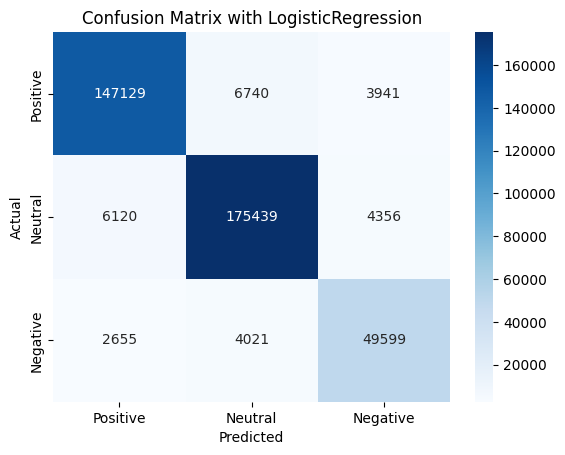

In [ ]:
#Test using LogisticRegression
from sklearn.linear_model import LogisticRegression

modelLogistic=LogisticRegression(max_iter=3000,solver='liblinear',class_weight='balanced',C=0.5)
modelLogistic.fit(X_train_final,y_train)

y_predRegression=modelLogistic.predict(X_test_final)

print(f"Global Accuracy with LogisticRegression: {accuracy_score(y_test,y_predRegression):.2f}\n")
print(classification_report(y_test,y_predRegression))

cmr=confusion_matrix(y_test,y_predRegression,labels=["Positive","Neutral","Negative"])
sns.heatmap(cmr,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Neutral","Negative"],yticklabels=["Positive","Neutral","Negative"])
plt.title("Confusion Matrix with LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()